# Monte Carlo methods to estimate joint force distributions
We learned how reduction method can be used to calculate the joint reaction force at the elbow if all geometric variables (muscle force insertion angles, moment arms, muscle cross-sectional areas) are given.

What if we can't measure them for an individual, but have a good sense of population values?  Can we estimate a probability of a joint reaction force falling in a particular range?

Here we will work with the mean and standard deviation for our geometric variables to estimate the range of joint reaction forces generated in this simple motion.

**Extension:** we add a **fourth muscle** (force $F_4$, insertion angle $\theta_4$) acting about the same elbow joint, alongside the same reduction-method framework used for muscles 1-3. Muscle insertion angles, moment arms, and PCSA for all four muscles are perturbed as **normal distributions**, matching the original model.

**Population data substitution:** all population values below (PCSA, moment arm, insertion angle, and the book/load moment arm $c$) are now taken from Table 1 (elbow JRF problem muscle data) for four real elbow muscles -- **brachialis (BRA)**, **biceps brachii (BIC)**, **brachioradialis (BRD)**, and **pronator teres (PRO)** -- assigned to muscles 1-4 respectively.

### Assumptions made to complete this substitution
1. Table 1 reports **min/max ranges**, not mean/SD. We take mean = (min+max)/2 and SD = (max-min)/4, i.e. we assume the reported range spans roughly $\pm 2$ SD (about 95% of a normal distribution) around the mean.
2. Muscle-to-index mapping: M1 = brachialis (BRA), M2 = biceps brachii (BIC), M3 = brachioradialis (BRD), M4 = pronator teres (PRO). This assignment is arbitrary -- the physics/ratios are unaffected by which muscle is labeled M1-M4.
3. $F_B$ is given in Table 1 as a single fixed value (20 N), not a range, so it is treated as deterministic rather than sampled.
4. The load/book moment arm $c$ is sampled as normal (mean 33 cm, SD 4.5 cm) from Table 1's given range (24-42 cm), consistent with how the original model treated $c$.
5. Table 1 does not provide the forearm segment weight or its center-of-mass moment arm ($b$), so the original model's own internal relationship is kept unchanged: $b = c/2$ and $F_G = b\cdot(20/15)$ ("let weight of the ulna scale with the length of the ulna"), as in the initial file.
6. All four muscles' insertion angles, moment arms, and PCSA are sampled independently from normal distributions (as in the original file), each with the mean/SD derived from Table 1 per assumption 1.
7. Sample size nsam = 30, matching the original file's default.

pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DEFINE THE BOOK IN THE HAND AS A KNOWN AND ALL OTHER GEOMETRIC VARIABLES AS A NORMAl DISTRIBUTION OF VALUES
FB = 20; # weight of the book in N (Table 1, given as a single fixed value)
nsam = 30; # number of samples to include in the dataset

c, c_SD = 33, 4.5 ; # mean and SD of moment arm for the book weight (cm), from Table 1 range 24-42
ulna = np.random.normal(c, c_SD, nsam); 
ulna_gravity = ulna/2; # these are values for b in the problem, should correlate with c
FG = ulna_gravity*20/15; # let weight of the ulna scale with the length of the ulna

# print(ulna_gravity);

# define muscle insertion angles in degrees and convert to radians
# M1 = brachialis (BRA), Table 1 theta range 75-85 deg
a_M1, a_M1_SD = np.deg2rad(80), np.deg2rad(2.5); 
a_M1_array=np.random.normal(a_M1, a_M1_SD, nsam); 

# M2 = biceps brachii (BIC), Table 1 theta range 65-75 deg
a_M2, a_M2_SD = np.deg2rad(70), np.deg2rad(2.5);
a_M2_array=np.random.normal(a_M2, a_M2_SD, nsam); 

# M3 = brachioradialis (BRD), Table 1 theta range 12-24 deg
a_M3, a_M3_SD = np.deg2rad(18), np.deg2rad(3); 
a_M3_array=np.random.normal(a_M3, a_M3_SD, nsam); 

# M4 = pronator teres (PRO), Table 1 theta range 65-78 deg
a_M4, a_M4_SD = np.deg2rad(71.5), np.deg2rad(3.25); 
a_M4_array=np.random.normal(a_M4, a_M4_SD, nsam); 

# define muscle moment arms in cm (Table 1 column 'a')
# M1 = brachialis, range 1.3-4.2 cm
l_M1, l_M1_SD = 2.75, 0.725; 
l_M1_array=np.random.normal(l_M1, l_M1_SD, nsam); 

# M2 = biceps brachii, range 2.1-8.9 cm
l_M2, l_M2_SD = 5.5, 1.7;
l_M2_array=np.random.normal(l_M2, l_M2_SD, nsam); 

# M3 = brachioradialis, range 15.5-25.2 cm
l_M3, l_M3_SD = 20.35, 2.425; 
l_M3_array=np.random.normal(l_M3, l_M3_SD, nsam); 

# M4 = pronator teres, range 0.8-2.5 cm
l_M4, l_M4_SD = 1.65, 0.425; 
l_M4_array=np.random.normal(l_M4, l_M4_SD, nsam); 

# define PCSA in cm^2 (Table 1 column 'PCSA')
# M1 = brachialis, range 4.8-12.5 cm^2
PCSA_M1, PCSA_M1_SD = 8.65, 1.925; 
PCSA_M1_array=np.random.normal(PCSA_M1, PCSA_M1_SD, nsam); 

# M2 = biceps brachii, range 2.4-13.0 cm^2
PCSA_M2, PCSA_M2_SD = 7.7, 2.65; 
PCSA_M2_array=np.random.normal(PCSA_M2, PCSA_M2_SD, nsam); 

# M3 = brachioradialis, range 1.6-8.1 cm^2
PCSA_M3, PCSA_M3_SD = 4.85, 1.625; 
PCSA_M3_array=np.random.normal(PCSA_M3, PCSA_M3_SD, nsam); 

# M4 = pronator teres, range 0.8-2.7 cm^2
PCSA_M4, PCSA_M4_SD = 1.75, 0.475; 
PCSA_M4_array=np.random.normal(PCSA_M4, PCSA_M4_SD, nsam); 

# ALL NORMALLY DISTRIBUTED VARIABLES ARE DEFINED

In [2]:
# MOVING ON TO SOLVE FOR THE UNKNOWNS
# for an integer digit between 1 and nsam, select an element of each normally distributed array
# first calculate Numerator N

N = np.array([0.0] * nsam, dtype=np.float16);
ratio12 = np.array([0.0] * nsam, dtype=np.float16);
ratio13 = np.array([0.0] * nsam, dtype=np.float16);
ratio14 = np.array([0.0] * nsam, dtype=np.float16);
denom = np.array([0.0] * nsam,dtype=np.float16);
F1_array = np.array([0.0] * nsam,dtype=np.float16);
F2_array = np.array([0.0] * nsam,dtype=np.float16);
F3_array = np.array([0.0] * nsam,dtype=np.float16);
F4_array = np.array([0.0] * nsam,dtype=np.float16);


for i in range(nsam):
    N[i] = (FG[i])*(ulna_gravity[i])+FB*ulna[i];

# Reduce D to a dependence on F1 only (denominator)
# F2 = k12*F1, F3 = k13*F1, F4 = k14*F1 where k1j = PCSAj/PCSA1
    ratio12[i] = (PCSA_M2_array[i])/(PCSA_M1_array[i]);
    ratio13[i] = (PCSA_M3_array[i])/(PCSA_M1_array[i]);
    ratio14[i] = (PCSA_M4_array[i])/(PCSA_M1_array[i]);
    
# print("This is range of numerator values:", N);

    denom[i]=(l_M1_array[i])*np.sin(a_M1_array[i])+(l_M2_array[i])*np.sin(a_M2_array[i])*(ratio12[i])+(l_M3_array[i])*np.sin(a_M3_array[i])*(ratio13[i])+(l_M4_array[i])*np.sin(a_M4_array[i])*(ratio14[i]); # calculate all known terms in denominator

# We are ready to obtain the solution for F1
    F1_array[i] = N[i]/(denom[i]);
    F2_array[i] = ratio12[i]*(F1_array[i]);
    F3_array[i] = ratio13[i]*(F1_array[i]);
    F4_array[i] = ratio14[i]*(F1_array[i]);

# print("The force in muscle 4 in N:" ,F4_array)


In [3]:
# And what is the joint reaction force?
JointX = np.array([0.0] * nsam,dtype=np.float32);
JointY = np.array([0.0] * nsam,dtype=np.float32);
mag = np.array([0.0] * nsam,dtype=np.float32);
angle = np.array([0.0]*nsam,dtype=np.float32);
angled = np.array([0.0]*nsam,dtype=np.float32);


# Define the x-component and y-component of the joint reaction force
for i in range(nsam):
    JointX[i]=-F1_array[i]*np.cos(a_M1_array[i]) + -F2_array[i]*np.cos(a_M2_array[i])+ -F3_array[i]*np.cos(a_M3_array[i]) + -F4_array[i]*np.cos(a_M4_array[i]); # calculate all known terms in denominator
    JointY[i]=F1_array[i]*np.sin(a_M1_array[i])+F2_array[i]*np.sin(a_M2_array[i])+F3_array[i]*np.sin(a_M3_array[i])+F4_array[i]*np.sin(a_M4_array[i])-FG[i]-FB; 

# Calculate the magnitude of the joint reaction force and the direction (angle)

for i in range(nsam):
    mag[i] = ((JointX[i]*JointX[i] + JointY[i]*JointY[i])**0.5);
    angle[i]= np.arctan(JointY[i]/JointX[i]); # angle in radians

angled = 180*angle/np.pi; # angle in degrees

# print("The joint reaction force has magnitude:", mag, "in N and acts with angle", angled, "in degrees");

Create a histogram or frequency plot for the magnitude of the joint reaction forces next

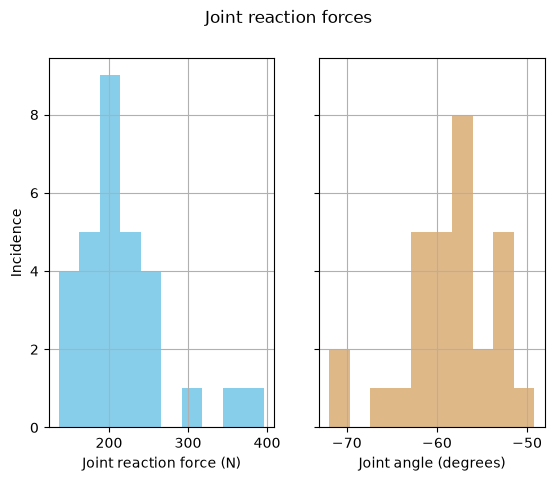

In [4]:
# Frequency distributions.
fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
axs[0].hist(mag, bins=10, color='skyblue')
axs[1].hist(angled, bins=10, color='burlywood')

fig.suptitle("Joint reaction forces")

axs[0].set_xlabel("Joint reaction force (N)")
axs[1].set_xlabel("Joint angle (degrees)")
axs[0].set_ylabel("Incidence")

for ax in axs:
    ax.grid(True)

plt.show()

Now examine the distribution of the fourth muscle's (pronator teres) force $F_4$ and its insertion angle $\theta_4$ across the Monte Carlo population, alongside the forces in muscles 1-3 (brachialis, biceps brachii, brachioradialis).

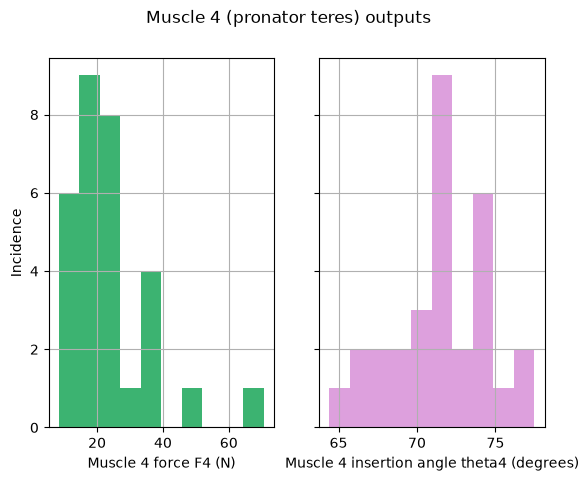

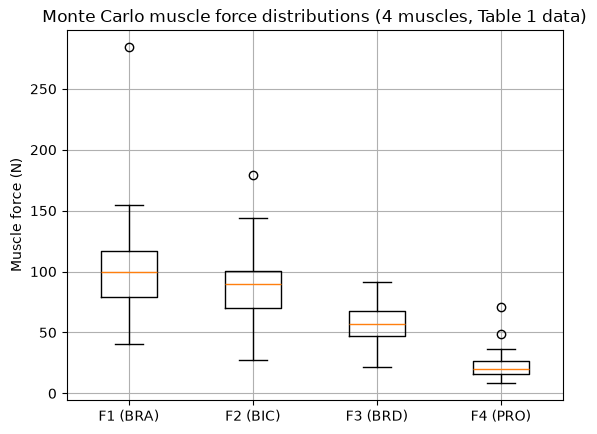

In [5]:
# Frequency distributions for Muscle 4 (pronator teres): force F4 and insertion angle theta4
fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
axs[0].hist(F4_array, bins=10, color='mediumseagreen')
axs[1].hist(np.rad2deg(a_M4_array), bins=10, color='plum')

fig.suptitle("Muscle 4 (pronator teres) outputs")

axs[0].set_xlabel("Muscle 4 force F4 (N)")
axs[1].set_xlabel("Muscle 4 insertion angle theta4 (degrees)")
axs[0].set_ylabel("Incidence")

for ax in axs:
    ax.grid(True)

plt.show()

# Compare all four muscle forces side by side
fig2, ax2 = plt.subplots()
ax2.boxplot([F1_array, F2_array, F3_array, F4_array], tick_labels=['F1 (BRA)', 'F2 (BIC)', 'F3 (BRD)', 'F4 (PRO)'])
ax2.set_ylabel("Muscle force (N)")
ax2.set_title("Monte Carlo muscle force distributions (4 muscles, Table 1 data)")
ax2.grid(True)
plt.show()